In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/processed/fiscal_consolidated.csv")

monthly_summary = pd.read_csv("../outputs/tables/monthly_tax_summary.csv")
tax_by_state = pd.read_csv("../outputs/tables/tax_by_state.csv")
tax_by_cfop = pd.read_csv("../outputs/tables/tax_by_cfop.csv")
inconsistency_summary = pd.read_csv("../outputs/tables/inconsistency_summary.csv")
inconsistency_report = pd.read_csv("../outputs/tables/inconsistency_report.csv")

df.head()

,invoice_id,issue_date,customer_state,operation_type,cfop,cst,product_category,gross_value,discount_value,freight_value,net_value,icms_rate,pis_rate,cofins_rate,tax_base,icms_value,pis_value,cofins_value,total_tax_value,estimated_tax_burden,source_file,month,calculated_net_value,calculated_total_tax,tax_burden_check
0,NF-2025-01-00001,2025-01-01 00:00:00,BA,Venda,6102.0,41.0,Serviços,452.28,112.81,142.58,482.05,0.12,0.0165,0.076,0.00,0.00,0.00,0.00,0.00,0.00,invoices_2025-01.xlsx,2025-01,482.05,0.00,0.00
1,NF-2025-01-00002,2025-01-01 01:00:00,SP,Venda,5933.0,41.0,Eletrônicos,1521.12,72.18,101.72,1550.66,0.18,0.0165,0.076,0.00,0.00,0.00,0.00,0.00,0.00,invoices_2025-01.xlsx,2025-01,1550.66,0.00,0.00
2,NF-2025-01-00003,2025-01-01 02:00:00,BA,Venda,6102.0,0.0,Serviços,1920.19,105.41,108.07,1922.85,0.12,0.0165,0.076,1922.85,230.74,31.73,146.14,408.61,21.25,invoices_2025-01.xlsx,2025-01,1922.85,408.61,21.25
3,NF-2025-01-00004,2025-01-01 03:00:00,PR,Venda,6102.0,0.0,Eletrônicos,1115.57,47.08,184.33,1252.82,0.12,0.0165,0.076,1252.82,150.34,20.67,95.21,266.22,21.25,invoices_2025-01.xlsx,2025-01,1252.82,266.22,21.25
4,NF-2025-01-00005,2025-01-01 04:00:00,RJ,Venda,6933.0,0.0,Eletrônicos,1934.97,92.24,104.48,1947.21,0.12,0.0165,0.076,1947.21,233.67,32.13,147.99,413.79,21.25,invoices_2025-01.xlsx,2025-01,1947.21,413.79,21.25


In [4]:
df.shape

(3210, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3210 entries, 0 to 3209
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   invoice_id            3210 non-null   object 
 1   issue_date            3210 non-null   object 
 2   customer_state        3210 non-null   object 
 3   operation_type        3210 non-null   object 
 4   cfop                  3179 non-null   float64
 5   cst                   3179 non-null   float64
 6   product_category      3210 non-null   object 
 7   gross_value           3210 non-null   float64
 8   discount_value        3210 non-null   float64
 9   freight_value         3210 non-null   float64
 10  net_value             3210 non-null   float64
 11  icms_rate             3210 non-null   float64
 12  pis_rate              3210 non-null   float64
 13  cofins_rate           3210 non-null   float64
 14  tax_base              3210 non-null   float64
 15  icms_value           

In [6]:
total_invoices = len(df)
total_net_revenue = df["calculated_net_value"].sum()
total_tax = df["calculated_total_tax"].sum()
tax_burden = total_tax / total_net_revenue * 100
total_inconsistencies = len(inconsistency_report)
inconsistency_rate = total_inconsistencies / total_invoices * 100

print(f"Total de notas fiscais: {total_invoices:,}")
print(f"Faturamento líquido: R$ {total_net_revenue:,.2f}")
print(f"Total estimado de tributos: R$ {total_tax:,.2f}")
print(f"Carga tributária estimada: {tax_burden:.2f}%")
print(f"Notas com inconsistência: {total_inconsistencies:,}")
print(f"Percentual de inconsistências: {inconsistency_rate:.2f}%")

Total de notas fiscais: 3,210
Faturamento líquido: R$ 5,877,249.83
Total estimado de tributos: R$ 844,659.45
Carga tributária estimada: 14.37%
Notas com inconsistência: 79
Percentual de inconsistências: 2.46%


In [7]:
def add_horizontal_labels(ax, fmt="{:,.2f}", offset=5):
    for p in ax.patches:
        value = p.get_width()
        ax.annotate(
            fmt.format(value),
            (value, p.get_y() + p.get_height() / 2),
            xytext=(offset, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9
        )


def add_vertical_labels(ax, fmt="{:,.2f}", offset=5):
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(
            fmt.format(value),
            (p.get_x() + p.get_width() / 2, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

In [8]:
Path("../outputs/charts").mkdir(parents=True, exist_ok=True)

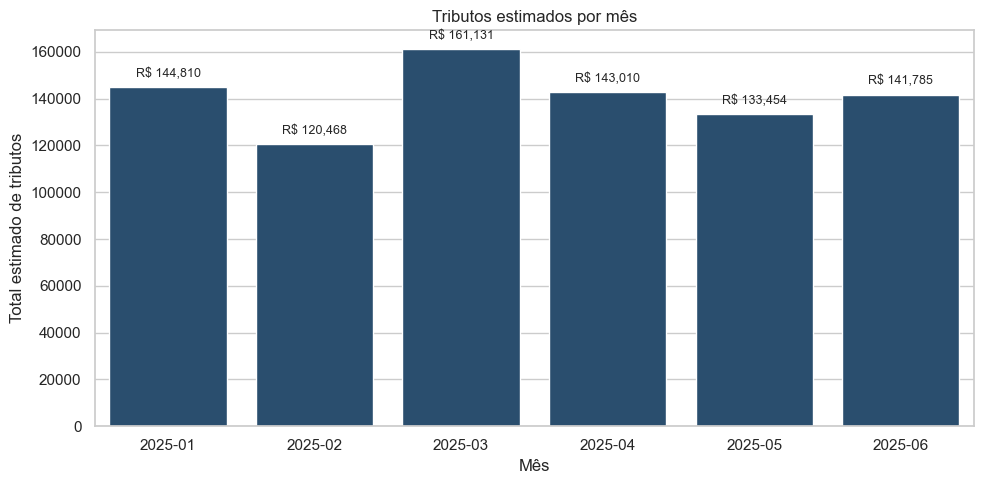

In [9]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=monthly_summary,
    x="month",
    y="total_tax",
    color="#1F4E79"
)

plt.title("Tributos estimados por mês")
plt.xlabel("Mês")
plt.ylabel("Total estimado de tributos")

add_vertical_labels(ax, "R$ {:,.0f}")

plt.tight_layout()
plt.savefig("../outputs/charts/monthly_tax_amount.png", dpi=150)
plt.show()

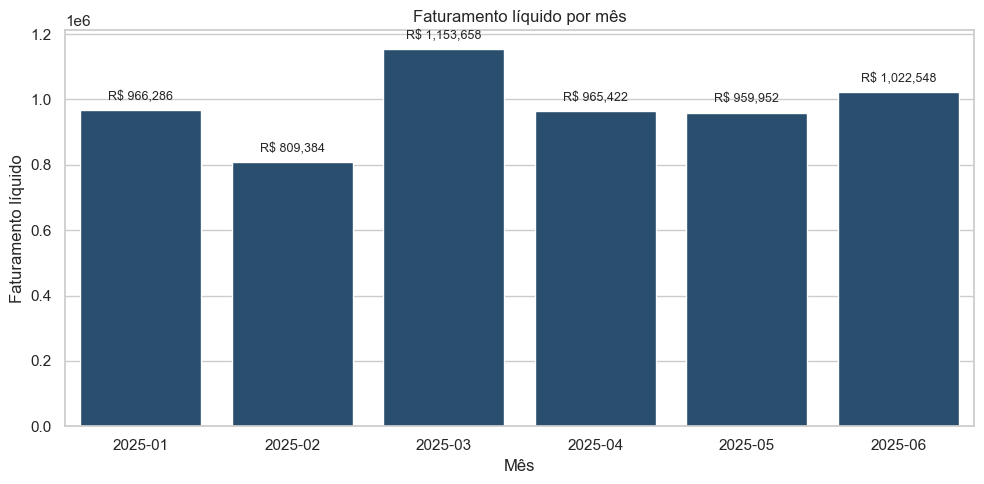

In [10]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=monthly_summary,
    x="month",
    y="net_revenue",
    color="#1F4E79"
)

plt.title("Faturamento líquido por mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento líquido")

add_vertical_labels(ax, "R$ {:,.0f}")

plt.tight_layout()
plt.savefig("../outputs/charts/monthly_net_revenue.png", dpi=150)
plt.show()

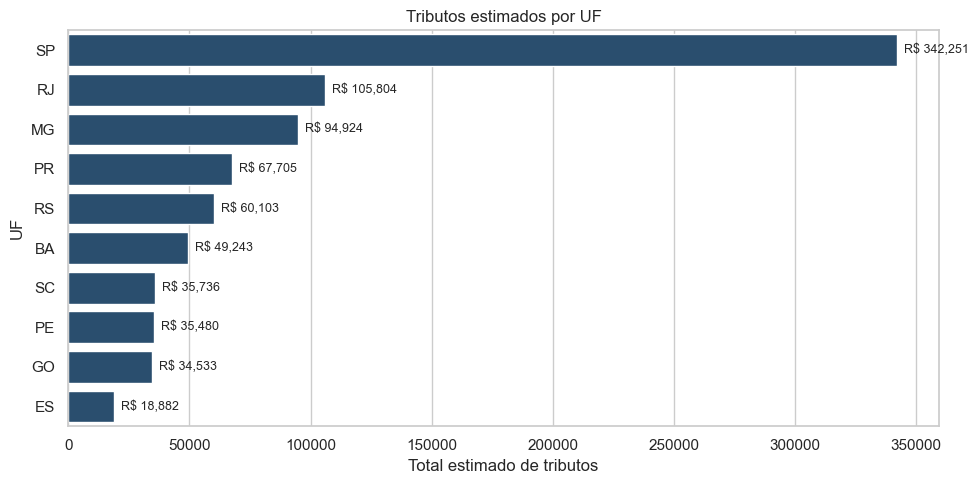

In [12]:
tax_by_state_plot = tax_by_state.sort_values("total_tax", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=tax_by_state_plot,
    x="total_tax",
    y="customer_state",
    color="#1F4E79"
)

plt.title("Tributos estimados por UF")
plt.xlabel("Total estimado de tributos")
plt.ylabel("UF")

add_horizontal_labels(ax, "R$ {:,.0f}")

plt.tight_layout()
plt.savefig("../outputs/charts/tax_by_state.png", dpi=150)
plt.show()

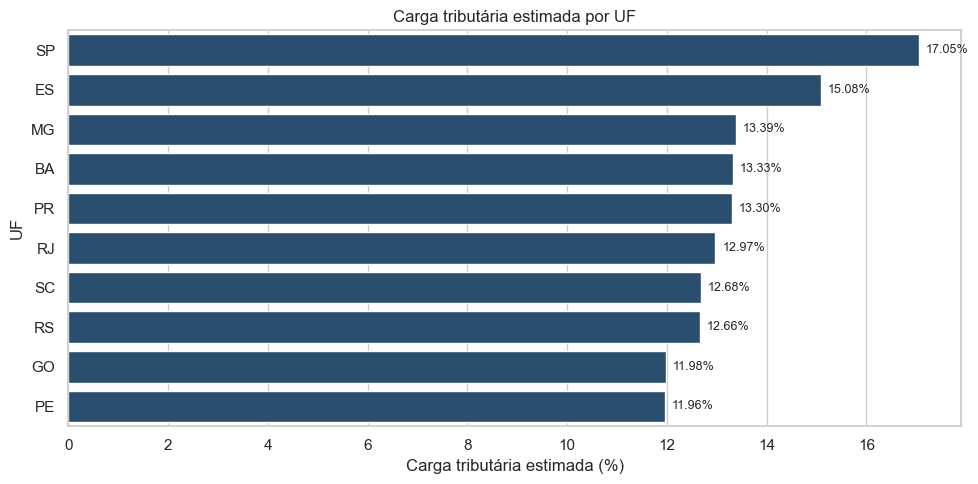

In [13]:
tax_burden_by_state = tax_by_state.sort_values("estimated_tax_burden", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=tax_burden_by_state,
    x="estimated_tax_burden",
    y="customer_state",
    color="#1F4E79"
)

plt.title("Carga tributária estimada por UF")
plt.xlabel("Carga tributária estimada (%)")
plt.ylabel("UF")

add_horizontal_labels(ax, "{:.2f}%")

plt.tight_layout()
plt.savefig("../outputs/charts/tax_burden_by_state.png", dpi=150)
plt.show()

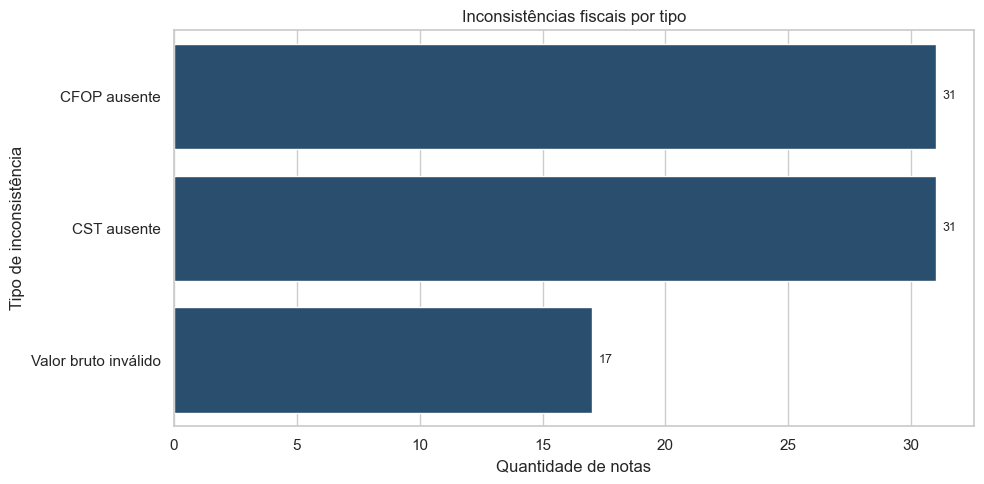

In [14]:
inconsistency_plot = inconsistency_summary.sort_values("invoices", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=inconsistency_plot,
    x="invoices",
    y="inconsistency_type",
    color="#1F4E79"
)

plt.title("Inconsistências fiscais por tipo")
plt.xlabel("Quantidade de notas")
plt.ylabel("Tipo de inconsistência")

add_horizontal_labels(ax, "{:.0f}")

plt.tight_layout()
plt.savefig("../outputs/charts/inconsistencies_by_type.png", dpi=150)
plt.show()

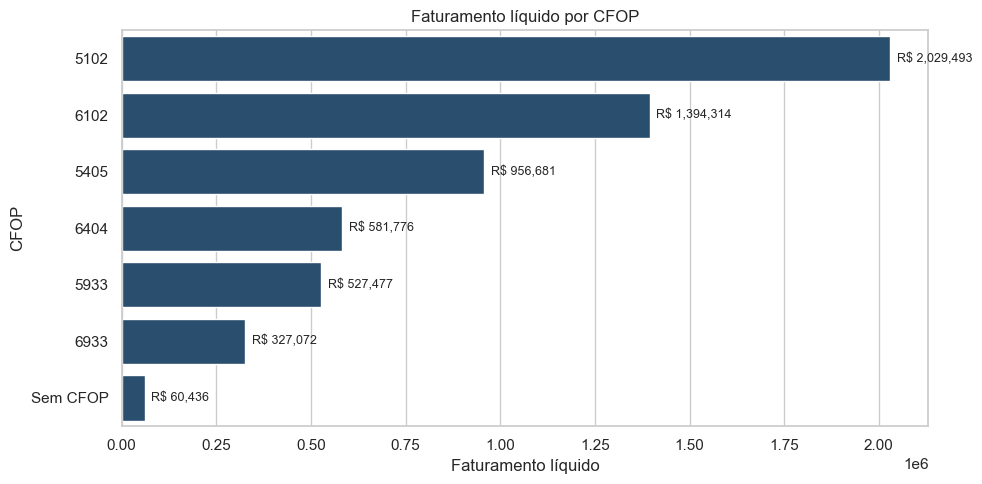

In [18]:
tax_by_cfop_plot = tax_by_cfop.copy()

tax_by_cfop_plot["cfop"] = (
    tax_by_cfop_plot["cfop"]
    .fillna("Sem CFOP")
    .astype(str)
    .str.replace(".0", "", regex=False)
)

tax_by_cfop_plot = tax_by_cfop_plot.sort_values("net_revenue", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=tax_by_cfop_plot,
    x="net_revenue",
    y="cfop",
    color="#1F4E79"
)

plt.title("Faturamento líquido por CFOP")
plt.xlabel("Faturamento líquido")
plt.ylabel("CFOP")

add_horizontal_labels(ax, "R$ {:,.0f}")

plt.tight_layout()
plt.savefig("../outputs/charts/net_revenue_by_cfop.png", dpi=150)
plt.show()

## Leitura dos resultados

A automação consolidou os arquivos mensais de notas fiscais em uma base única e gerou indicadores de apoio à conferência fiscal.

Os principais indicadores analisados foram faturamento líquido, tributos estimados, carga tributária estimada e inconsistências nos dados fiscais.

A análise mensal ajuda a acompanhar a evolução dos valores consolidados, enquanto a visão por UF e CFOP facilita a identificação de concentrações relevantes nas operações.

O relatório de inconsistências aponta registros que precisariam de revisão antes de um fechamento fiscal, como notas com CFOP ou CST ausente e valores brutos inválidos.

## Conclusões

O pipeline simulou uma rotina de fechamento fiscal mensal, consolidando arquivos, calculando tributos estimados e gerando saídas para análise.

Mesmo com regras fiscais simplificadas, o projeto mostra como uma rotina manual em planilhas pode ser organizada em um fluxo automatizado.

Os principais ganhos esperados são:

- redução de trabalho manual;
- padronização da base fiscal;
- identificação rápida de inconsistências;
- geração de tabelas e gráficos para conferência;
- melhor rastreabilidade da execução por meio de logs.

## Próximos passos possíveis

- Criar validações adicionais por CFOP e CST.
- Adicionar regras por UF.
- Gerar relatório em Excel com abas separadas.
- Criar um dashboard em Power BI.
- Agendar a execução automática do pipeline.